<a href="https://colab.research.google.com/github/jddurnn777/EEL4810_CIFAR10_TransferLearning_Project/blob/main/VIT_baseline4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

website 1: https://medium.com/@akshay.m.gokhale/training-a-vision-transformer-from-scratch-on-cifar-10-7804248048d9

website 2: https://github.com/kentaroy47/vision-transformers-cifar10

In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.transforms import v2
from torch.optim.lr_scheduler import OneCycleLR
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [8]:
# From article (WiT-Tiny style setup)
# image size: 32x32, patch size: 4x4, number of patches is 64 (32 / 4)(32 / 4), embedding dimension is 192, transformer depth is 12, and 3 attention heads

#Dataset + img settings
image_size = 32 # Keep 32 for consistent patch embedding as in ViT-Tiny
num_classes = 10
in_channels = 1 # MNIST is grayscale, so 1 channel

#ViT architecture
patch_size = 4
embed_dim = 192
depth = 12
num_heads = 3
mlp_ratio = 4.0
dropout = 0.1
attention_dropout = 0.1

#Training
batch_size = 128
epochs = 30
lr = 5e-4
weight_decay = 0.05

#Data split
validation_fraction = 0.1

class Config:
    def __init__(self):
        self.image_size = image_size
        self.num_classes = num_classes
        self.in_channels = in_channels
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.depth = depth
        self.num_heads = num_heads
        self.mlp_ratio = mlp_ratio
        self.dropout = dropout
        self.attention_dropout = attention_dropout
        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.weight_decay = weight_decay
        self.validation_fraction = validation_fraction

cfg = Config()

#MNIST with 4x4 patches on 32x32 images gives 64 patch tokens.
num_patches = (cfg.image_size // cfg.patch_size) ** 2
print("Number of patches:", num_patches)

#Class names for MNIST (0-9)
class_names = [str(i) for i in range(10)]

#Data transforms and augmentation for MNIST
# We will resize MNIST 28x28 images to 32x32 to match the ViT architecture.
MNIST_MEAN = (0.1307,)
MNIST_STD = (0.3081,)

train_transform = transforms.Compose([
    transforms.Resize(cfg.image_size), # Resize to 32x32
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD),
])

test_transform = transforms.Compose([
    transforms.Resize(cfg.image_size), # Resize to 32x32
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD),
])

Number of patches: 64


100%|██████████| 9.91M/9.91M [00:00<00:00, 62.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.64MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.52MB/s]


Train size: 54000
Validation size: 6000
Test size: 10000


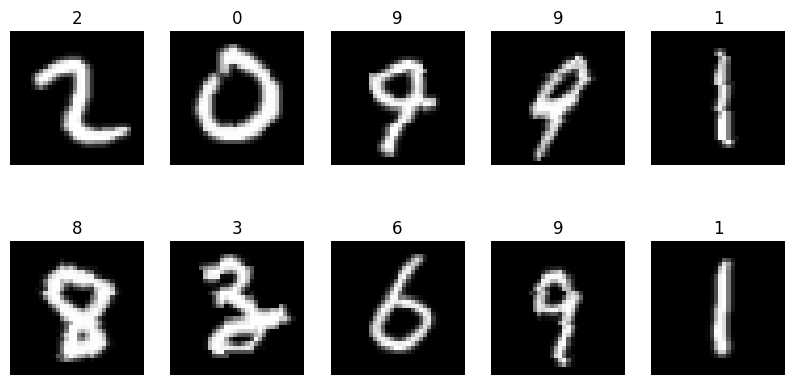

In [9]:
# download MNIST and split the training set into 2 sets

data_root = "./data"

full_train_dataset = datasets.MNIST(
    root=data_root,
    train=True,
    download=True,
    transform=train_transform,
)

#For validation, we need a version of the same MNIST training set
# but with test/validation transforms instead of training augmentation

full_val_dataset = datasets.MNIST(
    root=data_root,
    train=True,
    download=True,
    transform=test_transform,
)

test_dataset = datasets.MNIST(
    root=data_root,
    train=False,
    download=True,
    transform=test_transform,
)

val_size = int(len(full_train_dataset) * cfg.validation_fraction)
train_size = len(full_train_dataset) - val_size

#split indices once, then use same indices for train and validation

generator = torch.Generator().manual_seed(SEED)
train_subset_aug, val_subset_aug = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

#validation subset above has the right indices but the wrong transform
# because it came from full_train_dataset
# so we reuse its indices on full_val_dataset

val_indices = val_subset_aug.indices
train_indices = train_subset_aug.indices

train_dataset = torch.utils.data.Subset(full_train_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_val_dataset, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

#bc images were normalized, we unnormalize them before plotting

def unnormalize(img_tensor, mean=MNIST_MEAN, std=MNIST_STD):
  # MNIST is single channel, so view as (1,1,1) for broadcasting
  mean = torch.tensor(mean).view(1, 1, 1)
  std = torch.tensor(std).view(1, 1, 1)
  return img_tensor.cpu() * std + mean

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(10):
  # Unnormalize using MNIST_MEAN and MNIST_STD
  img = unnormalize(images[i], mean=MNIST_MEAN, std=MNIST_STD)
  # Squeeze the channel dimension for grayscale image display
  img = img.squeeze(0).clamp(0,1)
  plt.subplot(2,5,i+1)
  # Use 'gray' colormap for grayscale images
  plt.imshow(img, cmap='gray')
  plt.title(class_names[labels[i]])
  plt.axis('off')
plt.show()

Since the automatic download of CIFAR-10 is failing due to a server error, we will try to download the dataset manually using `wget`. This will place the `.tar.gz` file in the specified `data_root` directory, which `torchvision` can then use.

In [6]:
# Ensure the data directory exists
import os
if not os.path.exists(data_root):
    os.makedirs(data_root)

# Manual download of CIFAR-10 using wget
# The URL for CIFAR-10 is typically: https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
cifar_url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
cifar_filename = os.path.join(data_root, "cifar-10-python.tar.gz")

# Check if the file already exists to avoid re-downloading
if not os.path.exists(cifar_filename):
    print(f"Attempting to download CIFAR-10 from {cifar_url}...")
    !wget -O {cifar_filename} {cifar_url}
    print("Download complete. Retrying dataset loading.")
else:
    print(f"CIFAR-10 archive already found at {cifar_filename}. Skipping download.")

# Now, re-attempt to load the dataset. torchvision should now find the file.
full_train_dataset = datasets.CIFAR10(
    root=data_root,
    train=True,
    download=False, # Set download to False as we've (potentially) manually downloaded it
    transform=train_transform,
)

full_val_dataset = datasets.CIFAR10(
    root=data_root,
    train=True,
    download=False,
    transform=test_transform,
)

test_dataset = datasets.CIFAR10(
    root=data_root,
    train=False,
    download=False,
    transform=test_transform,
)

val_size = int(len(full_train_dataset) * cfg.validation_fraction)
train_size = len(full_train_dataset) - val_size

generator = torch.Generator().manual_seed(SEED)
train_subset_aug, val_subset_aug = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

val_indices = val_subset_aug.indices
train_indices = train_subset_aug.indices

train_dataset = torch.utils.data.Subset(full_train_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_val_dataset, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

#bc images were normalized, we unnormalize them before plotting

def unnormalize(img_tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
  mean = torch.tensor(mean).view(3, 1, 1)
  std = torch.tensor(std).view(3,1,1)
  return img_tensor.cpu() * std + mean

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(10):
  img = unnormalize(images[i]).permute(1,2,0).clamp(0,1)
  plt.subplot(2,5,i+1)
  plt.imshow(img)
  plt.title(class_names[labels[i]])
  plt.axis('off')
plt.show()

Attempting to download CIFAR-10 from https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz...
--2026-05-03 00:42:21--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 503 Service Unavailable
2026-05-03 00:42:21 ERROR 503: Service Unavailable.

Download complete. Retrying dataset loading.


RuntimeError: Dataset not found or corrupted. You can use download=True to download it

Since direct download attempts failed, we will manually attempt to extract the `cifar-10-python.tar.gz` file using the `tarfile` module. This is important because `torchvision` expects the data to be in a specific uncompressed format after download.

In [7]:
import tarfile
import os

cifar_tgz_path = os.path.join(data_root, "cifar-10-python.tar.gz")
cifar_extract_path = data_root # Extract into the data_root directory

if os.path.exists(cifar_tgz_path):
    print(f"Found CIFAR-10 archive at {cifar_tgz_path}. Attempting to extract...")
    try:
        with tarfile.open(cifar_tgz_path, "r:gz") as tar:
            tar.extractall(path=cifar_extract_path)
        print("Extraction complete. Now retrying dataset loading with download=False.")

        # Re-attempt to load the dataset after manual extraction
        full_train_dataset = datasets.CIFAR10(
            root=data_root,
            train=True,
            download=False,
            transform=train_transform,
        )

        full_val_dataset = datasets.CIFAR10(
            root=data_root,
            train=True,
            download=False,
            transform=test_transform,
        )

        test_dataset = datasets.CIFAR10(
            root=data_root,
            train=False,
            download=False,
            transform=test_transform,
        )

        val_size = int(len(full_train_dataset) * cfg.validation_fraction)
        train_size = len(full_train_dataset) - val_size

        generator = torch.Generator().manual_seed(SEED)
        train_subset_aug, val_subset_aug = random_split(
            full_train_dataset,
            [train_size, val_size],
            generator=generator
        )

        val_indices = val_subset_aug.indices
        train_indices = train_subset_aug.indices

        train_dataset = torch.utils.data.Subset(full_train_dataset, train_indices)
        val_dataset = torch.utils.data.Subset(full_val_dataset, val_indices)

        train_loader = DataLoader(
            train_dataset,
            batch_size=cfg.batch_size,
            shuffle=True,
            num_workers=0,
            pin_memory=True,
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=cfg.batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=cfg.batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
        )

        print("Train size:", len(train_dataset))
        print("Validation size:", len(val_dataset))
        print("Test size:", len(test_dataset))

        #bc images were normalized, we unnormalize them before plotting

        def unnormalize(img_tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
          mean = torch.tensor(mean).view(3, 1, 1)
          std = torch.tensor(std).view(3,1,1)
          return img_tensor.cpu() * std + mean

        images, labels = next(iter(train_loader))

        plt.figure(figsize=(10,5))
        for i in range(10):
          img = unnormalize(images[i]).permute(1,2,0).clamp(0,1)
          plt.subplot(2,5,i+1)
          plt.imshow(img)
          plt.title(class_names[labels[i]])
          plt.axis('off')
        plt.show()

    except tarfile.ReadError:
        print(f"Error: {cifar_tgz_path} is not a valid tar.gz file or is corrupted. Please ensure a successful download.")
    except Exception as e:
        print(f"An unexpected error occurred during extraction: {e}")
else:
    print(f"CIFAR-10 archive not found at {cifar_tgz_path}. Cannot extract.")
    print("Please ensure the dataset is successfully downloaded before attempting extraction.")

Found CIFAR-10 archive at ./data/cifar-10-python.tar.gz. Attempting to extract...
Error: ./data/cifar-10-python.tar.gz is not a valid tar.gz file or is corrupted. Please ensure a successful download.


In [10]:
#MixUp and CutMix helper
#MixUp blends two images and their labels
#CutMix cuts a rectangular patch from one image and pastes it onto another image
#Bc the labels become soft abels, we use a loss function that can handle soft targets

def one_hot(labels, num_classes):
  return torch.zeros(labels.size(0), num_classes, device=labels.device).scatter_(1, labels.unsqueeze(1), 1)

def rand_bbox(size, lam):
  W = size[3]
  H = size[2]

  cut_ratio = math.sqrt(1.0 - lam)
  cut_w = int(W * cut_ratio)
  cut_h = int(H * cut_ratio)

  cx = np.random.randint(W)
  cy = np.random.randint(H)

  x1 = np.clip(cx - cut_w // 2, 0, W)
  y1 = np.clip(cy - cut_h // 2, 0, H)
  x2 = np.clip(cx + cut_w // 2, 0, W)
  y2 = np.clip(cy + cut_h // 2, 0, H)

  return x1, y1, x2, y2

def apply_mixup_or_cutmix(images, labels, num_classes, mixup_alpha=0.8, cutmix_alpha=1.0, prob=0.5):
  if random.random() > prob:
    return images, one_hot(labels, num_classes)

  batch_size = images.size(0)
  shuffled_indices = torch.randperm(batch_size, device=images.device)

  labels_onehot = one_hot(labels, num_classes)
  shuffled_labels_onehot = labels_onehot[shuffled_indices]

  use_cutmix = random.random() < 0.5

  if use_cutmix:
    lam = np.random.beta(cutmix_alpha, cutmix_alpha)
    x1, y1, x2, y2 = rand_bbox(images.size(), lam)

    mixed_images = images.clone()
    mixed_images[:, :, y1:y2, x1:x2] = images[shuffled_indices, :, y1:y2, x1:x2]

    patch_area = (x2 - x1) * (y2 - y1)
    total_area = images.size(2) * images.size(3)
    lam = 1.0 - patch_area / total_area

    mixed_labels = lam * labels_onehot + (1 - lam) * shuffled_labels_onehot

  else:
    lam = np.random.beta(mixup_alpha, mixup_alpha)
    mixed_images = lam * images + (1 - lam) * images[shuffled_indices]
    mixed_labels = lam * labels_onehot + (1 - lam) * shuffled_labels_onehot

  return mixed_images, mixed_labels

def soft_target_cross_entropy(logits, soft_targets):
  # Cross entropy for soft labels
  log_probs = torch.log_softmax(logits, dim=1)
  loss = -(soft_targets * log_probs).sum(dim=1).mean()
  return loss

In [11]:
# instead of feeding the img pixel by pixel, split into patches using a single conv2d layer where kernel_size = patch_size and stricde = patch_size

class PatchEmbedding(nn.Module):
  def __init__(self, image_size=32, patch_size=4, in_channels=3, embed_dim=192):
    super().__init__()

    self.image_size = image_size
    self.patch_size = patch_size
    self.num_patches = (image_size // patch_size) ** 2

    #this cuts the image into non-overlapping patches
    # projects each patch into an embedding vector

    self.patch_embed = nn.Conv2d(
        in_channels=in_channels,
        out_channels=embed_dim,
        kernel_size=patch_size,
        stride=patch_size,
    )

  def forward(self, x):
    x = self.patch_embed(x)
    #after conv: [batch, embed_dim, grid_height, grid_width]

    x = x.flatten(2)
    # Now: [batch, embed_dim, num_patches]

    x = x.transpose(1, 2)
    # now [ batch, num_patches, embed_dim]
    #This is the sequence format the transformer expects

    return x

In [12]:
#9 Multi-Head Self-Attention
#Self-attention lets each patch look at every other patch,
#for image classification, this helps the model learn relatuonships between far-apart parts of the image
# for example, it can connect the wheels and body of a truck even if they are in different patches

class MultiHeadSelfAttention(nn.Module):
  def __init__(self, embed_dim=192, num_heads=3, attention_dropout=0.1, projection_dropout=0.1):
    super().__init__()

    assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

    self.num_heads = num_heads
    self.head_dim = embed_dim // num_heads
    self.scale = self.head_dim ** -0.5

    # Create Q, K, and V together for efficiency
    self.qkv = nn.Linear(embed_dim, embed_dim*3)

    self.attn_drop = nn.Dropout(attention_dropout)
    self.proj = nn.Linear(embed_dim, embed_dim) # Corrected from == to =
    self.proj_drop = nn.Dropout(projection_dropout) # Corrected from == to =

  def forward(self, x):
    B, N, C = x.shape
    #B = batch size, N = sequence length (patches + CLS token), C = embedding dimension
    qkv = self.qkv(x)
    #Shape: [B, N, 3 * C]

    qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
    #Shape: [B, N, 3, heads, head_dim]

    qkv = qkv.permute(2, 0, 3, 1, 4)
    #Shape: [3, B, heads, N, head_dim]

    q, k, v = qkv[0], qkv[1], qkv[2]

    attention_scores = (q @ k.transpose(-2, -1)) * self.scale
    # Shape: [B, heads, N, N]

    attention_probs = attention_scores.softmax(dim=-1)
    attention_probs = self.attn_drop(attention_probs)

    context = attention_probs @ v
    # Shape: [B, Heads, N, head_dim]

    context = context.transpose(1,2).reshape(B, N, C)
    # Shape: [B, N, C]

    out = self.proj(context)
    out = self.proj_drop(out)

    return out

In [13]:
import torch.nn as nn

#10 Transformer Encoder Bkock
# Each encoder block has:
# LayerNorm, Multi-head self-attention, Residual connection, LayerNorm, MLP/feed-forward network, Residual connection
# this notebook uses Pre-Norm, meaning LayerNorm happens before attention and before the MLP. This usually makes training more stable.

# MLP Class Definition
class MLP(nn.Module): # Corrected: Added class definition for MLP
  def __init__(self, embed_dim=192, mlp_ratio=4.0, dropout=0.1): # Corrected typo mlp_raito -> mlp_ratio
    super().__init__() # Corrected typo supter -> super

    hidden_dim = int(embed_dim * mlp_ratio)

    self.net = nn.Sequential(
        nn.Linear(embed_dim, hidden_dim),
        nn.GELU(),
        nn.Dropout(dropout), # Corrected typo Droupout -> Dropout
        nn.Linear(hidden_dim, embed_dim),
        nn.Dropout(dropout),
    )

  def forward(self, x): # Corrected: Moved forward method outside __init__
    return self.net(x)

class TransformerEncoderBlock(nn.Module):
  def __init__(self, embed_dim=192, num_heads=3, mlp_ratio=4.0, dropout=0.1, attention_dropout=0.1):
    super().__init__()

    self.norm1 = nn.LayerNorm(embed_dim)
    self.attn = MultiHeadSelfAttention( # Corrected indentation
        embed_dim=embed_dim,
        num_heads=num_heads,
        attention_dropout=attention_dropout,
        projection_dropout=dropout
    )
    self.norm2 = nn.LayerNorm(embed_dim)
    self.mlp = MLP(
        embed_dim=embed_dim,
        mlp_ratio=mlp_ratio,
        dropout=dropout
    )
  def forward(self, x):
    x = x + self.attn(self.norm1(x))
    x = x + self.mlp(self.norm2(x))
    return x

In [14]:
# steps:
# 1) Convert image into patch embeddings
# 2) Add a learnable CLS token
# 3) Add positional embeddings
# 4) Pass the sequence through transformer blocks
# 5) Use final CLS tokemn through output classification

class VisionTransformer(nn.Module):
    def __init__(
        self,
        image_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=192,
        depth=12,
        num_heads=3,
        mlp_ratio=4.0,
        dropout=0.1,
        attention_dropout=0.1
    ):
        super().__init__()

        self.patch_embedding = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim
        )

        self.num_patches = self.patch_embedding.num_patches

        # The CLS token is a learned summary token.
        # At the end, we use this token to classify the whole image.
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Positional embeddings tell the model where each patch came from.
        # +1 because we also need a position for the CLS token.
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))

        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
                attention_dropout=attention_dropout
            )
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        # Final classifier.
        self.head = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        # Initialize learnable tokens and linear layers.
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.LayerNorm):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)
    def forward(self, x):
        B = x.size(0)

        x = self.patch_embedding(x)
        # Shape: [B, num_patches, embed_dim]

        cls_tokens = self.cls_token.expand(B, -1, -1)
        # Shape: [B, 1, embed_dim]

        x = torch.cat((cls_tokens, x), dim=1)
        # Shape: [B, num_patches + 1, embed_dim]

        x = x + self.pos_embed
        x = self.pos_drop(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        cls_output = x[:, 0]
        # Take only the CLS token.

        logits = self.head(cls_output)

        return logits


In [15]:
# create model, size of a ViT-Tiny model

model = VisionTransformer(
    image_size=cfg.image_size,
    patch_size=cfg.patch_size,
    in_channels=cfg.in_channels,
    num_classes=cfg.num_classes,
    embed_dim=cfg.embed_dim,
    depth=cfg.depth,
    num_heads=cfg.num_heads,
    mlp_ratio=cfg.mlp_ratio,
    dropout=cfg.dropout,
    attention_dropout=cfg.attention_dropout
).to(device)

num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 5,356,618
Trainable parameters: 5,356,618


In [16]:
# optimizer: AdamW which is Adam with better weight decay behavior
# OneCycleLR: learning rate statrs lower, rises, then gradually falls
optimizer = optim.AdamW(
    model.parameters(),
    lr=cfg.lr,
    weight_decay=cfg.weight_decay
)

scheduler = OneCycleLR(
    optimizer=optimizer,
    max_lr=cfg.lr,
    epochs=cfg.epochs,
    steps_per_epoch=len(train_loader)
)

In [17]:
# Accuracy helper
# During training with MixUp/CutMix, labels can be soft labels. For accuracy, we convert soft labels back to hard labels by taking the class with the ;argest label value
def accuracy_from_logits(logits, labels):
    predictions = logits.argmax(dim=1)

    # If labels are soft/one-hot, convert to class ids.
    if labels.dim() > 1:
        true_labels = labels.argmax(dim=1)
    else:
        true_labels = labels

    correct = (predictions == true_labels).sum().item()
    total = true_labels.size(0)

    return correct, total

In [18]:
# Training and evaluation Loops
# Training loop:
# 1) Gets a batch of images and labels.
# 2) Applies MixUp or cutMix
# 3) Runs the model
# 4) Computes soft-label cross entropy
# 5) backpropgation
# 6) updates the optimizer and scheduler

# Note - validation loop does not use MixUp/CutMix

def train_one_epoch(model, loader, optimizer, scheduler, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    progress = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress:
        images = images.to(device)
        labels = labels.to(device)

        # Apply batch-level regularization.
        mixed_images, mixed_labels = apply_mixup_or_cutmix(
            images,
            labels,
            num_classes=cfg.num_classes,
            mixup_alpha=0.8,
            cutmix_alpha=1.0,
            prob=0.5
        )

        optimizer.zero_grad()

        logits = model(mixed_images)
        loss = soft_target_cross_entropy(logits, mixed_labels)

        loss.backward()

         # Gradient clipping can help stabilize transformer training.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        correct, total = accuracy_from_logits(logits, mixed_labels)

        total_loss += loss.item() * images.size(0)
        total_correct += correct
        total_samples += total

        progress.set_postfix({
            "loss": total_loss / total_samples,
            "acc": total_correct / total_samples
        })

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc


@torch.no_grad()
def evaluate(model, loader, device, criterion=None):
    model.eval()

    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    progress = tqdm(loader, desc="Evaluating", leave=False)

    for images, labels in progress:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        correct, total = accuracy_from_logits(logits, labels)

        total_loss += loss.item() * images.size(0)
        total_correct += correct
        total_samples += total

        progress.set_postfix({
            "loss": total_loss / total_samples,
            "acc": total_correct / total_samples
        })

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc



In [19]:
#This cell trains the ViT and saves the best model based on validation accuracy

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
best_model_path = "best_vit_cifar10.pth"

for epoch in range(cfg.epochs):
    print(f"\\nEpoch {epoch + 1}/{cfg.epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scheduler,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"Val loss:   {val_loss:.4f} | Val acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved new best model with validation accuracy: {best_val_acc:.4f}")


\nEpoch 1/30


Training:   0%|          | 0/422 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

Train loss: 2.0970 | Train acc: 0.2316
Val loss:   1.8733 | Val acc:   0.3127
Saved new best model with validation accuracy: 0.3127
\nEpoch 2/30


Training:   0%|          | 0/422 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

Train loss: 0.4616 | Train acc: 0.9121
Val loss:   0.0435 | Val acc:   0.9912
Saved new best model with validation accuracy: 0.9912
\nEpoch 30/30


Training:   0%|          | 0/422 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

Train loss: 0.4974 | Train acc: 0.9029
Val loss:   0.0436 | Val acc:   0.9912


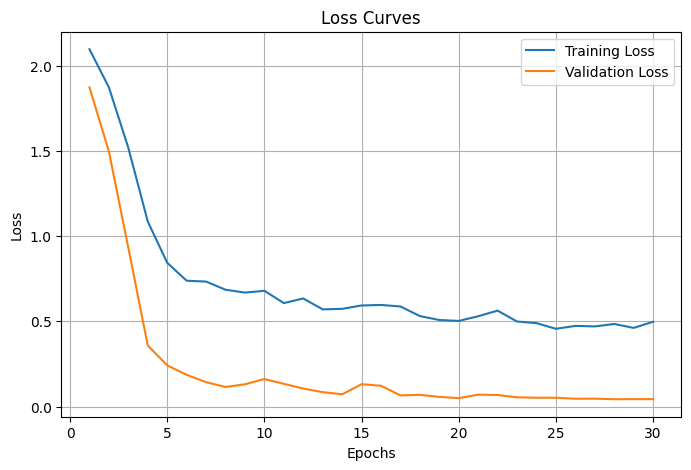

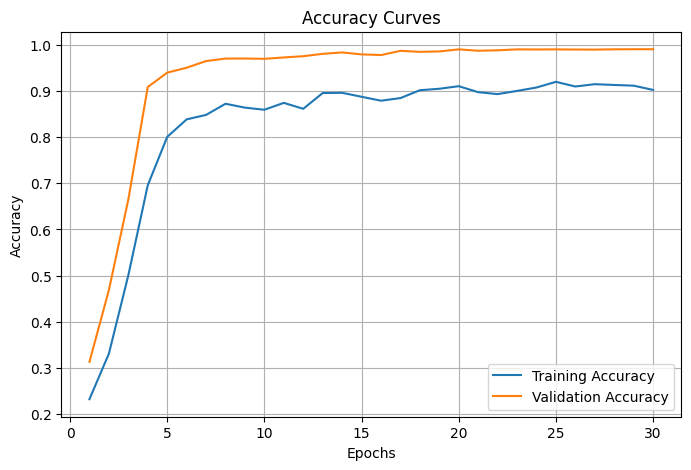

In [20]:
## Plot Training Curves

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs_range, history["train_loss"], label="Training Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="Training Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Test the best model
model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_acc = evaluate(model, test_loader, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Test loss: 0.0396
Test accuracy: 0.9920


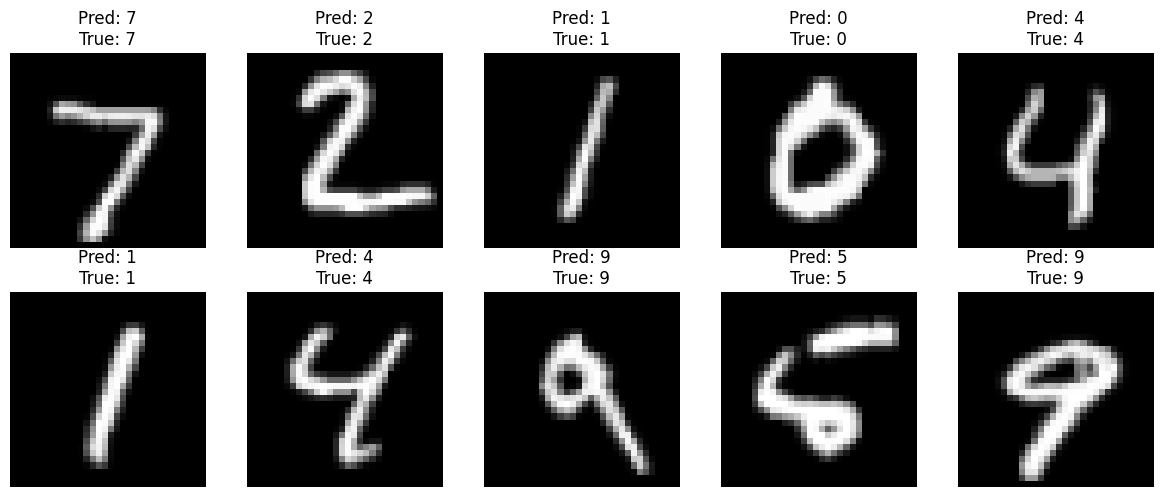

In [23]:
import matplotlib.pyplot as plt

# Show predictions
def show_predictions (model, loader, device, num_images=10):
  model.eval()

  # Define unnormalize specifically for MNIST to ensure correct parameters
  # as the global unnormalize might have been overwritten by CIFAR-10 attempts.
  def unnormalize_mnist(img_tensor, mean=MNIST_MEAN, std=MNIST_STD):
    # MNIST is single channel, so view as (1,1,1) for broadcasting
    mean = torch.tensor(mean).view(1, 1, 1)
    std = torch.tensor(std).view(1, 1, 1)
    return img_tensor.cpu() * std + mean

  images, labels = next(iter(loader))
  images = images.to(device)
  labels = labels.to(device)

  logits = model(images)
  predictions = logits.argmax(dim=1)

  plt.figure(figsize=(12,5))
  for i in range(num_images):
    # Use the local unnormalize_mnist function
    img = unnormalize_mnist(images[i]) # This will be (1, H, W) on CPU
    # Squeeze the channel dimension and convert to numpy for imshow
    img = img.squeeze(0).clamp(0,1).numpy()

    pred_name = class_names[predictions[i].item()]
    true_name = class_names[labels[i].item()]

    plt.subplot(2,5,i+1)
    plt.imshow(img, cmap='gray') # Specify cmap for grayscale
    plt.title(f"Pred: {pred_name}\nTrue: {true_name}")
    plt.axis('off')
  plt.tight_layout()
  plt.show()

show_predictions(model,test_loader,device)

<Figure size 900x900 with 0 Axes>

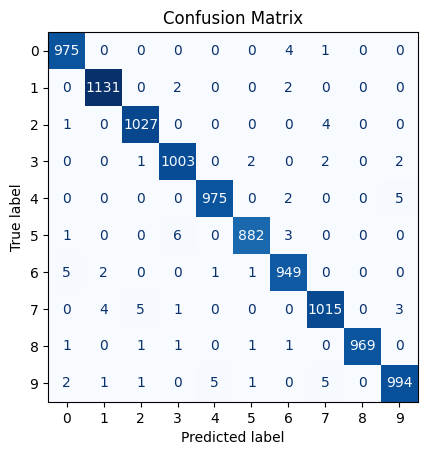

In [25]:
# Confusion  Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

@torch.no_grad()
def get_predictions(model,loader,device):
  model.eval()

  all_predictions = []
  all_labels = []

  for images, labels in tqdm(loader, desc="Collecting predictions"):
    images = images.to(device)
    labels = labels.to(device)

    logits = model(images)
    predictions = logits.argmax(dim=1)

    all_predictions.extend(predictions.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

  return np.array(all_labels), np.array(all_predictions)
true_labels, predicted_labels = get_predictions(model, test_loader, device)
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(9,9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d', colorbar=False)
plt.title("Confusion Matrix")
plt.show()

In [26]:
# Saving the final model

final_model_path = "final_vit_cifar10.pth"
torch.save(model.state_dict(), final_model_path)
print(f"Saved final model to {final_model_path}")

Saved final model to final_vit_cifar10.pth


In [27]:
from sklearn.metrics import classification_report

# true_labels and predicted_labels are available from the previous confusion matrix cell
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      1.00       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

